In [1]:
# 訓練データとテストデータの画像を読み込む
# （サイズは縦横224pxにリサイズする）
import tensorflow as tf

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "dog_cat_photos/train",
    image_size=(224, 224),
    label_mode="binary",
    batch_size=32,
    shuffle=True
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "dog_cat_photos/test",
    image_size=(224, 224),
    label_mode="binary",
    batch_size=32,
    shuffle=False
)

Found 300 files belonging to 2 classes.
Found 100 files belonging to 2 classes.


In [2]:
# データの詳細を表示する
list(train_dataset.as_numpy_iterator())[0]

(array([[[[205.      , 217.      , 205.      ],
          [205.03572 , 216.8683  , 204.91295 ],
          [210.39285 , 197.11383 , 191.8549  ],
          ...,
          [208.31474 , 208.31474 , 206.31474 ],
          [209.98886 , 209.98886 , 207.98886 ],
          [210.      , 210.      , 208.      ]],
 
         [[204.91518 , 216.84822 , 204.84375 ],
          [204.95078 , 216.71655 , 204.75664 ],
          [210.28847 , 196.96806 , 191.68962 ],
          ...,
          [208.28    , 208.28    , 206.25769 ],
          [209.9332  , 209.9332  , 207.91087 ],
          [209.9442  , 209.9442  , 207.92188 ]],
 
         [[192.19196 , 194.08035 , 181.40625 ],
          [192.20811 , 193.95468 , 181.31017 ],
          [194.63109 , 175.10303 , 166.89789 ],
          ...,
          [203.06932 , 203.06932 , 197.69879 ],
          [201.58354 , 201.58354 , 196.21301 ],
          [201.57365 , 201.57365 , 196.20312 ]],
 
         ...,
 
         [[ 77.29001 ,  75.95296 ,  79.60475 ],
          [ 77.307

In [ ]:
# 分類名（cat／dog）をリストとして格納する
class_names = train_dataset.class_names
class_names

['cat', 'dog']

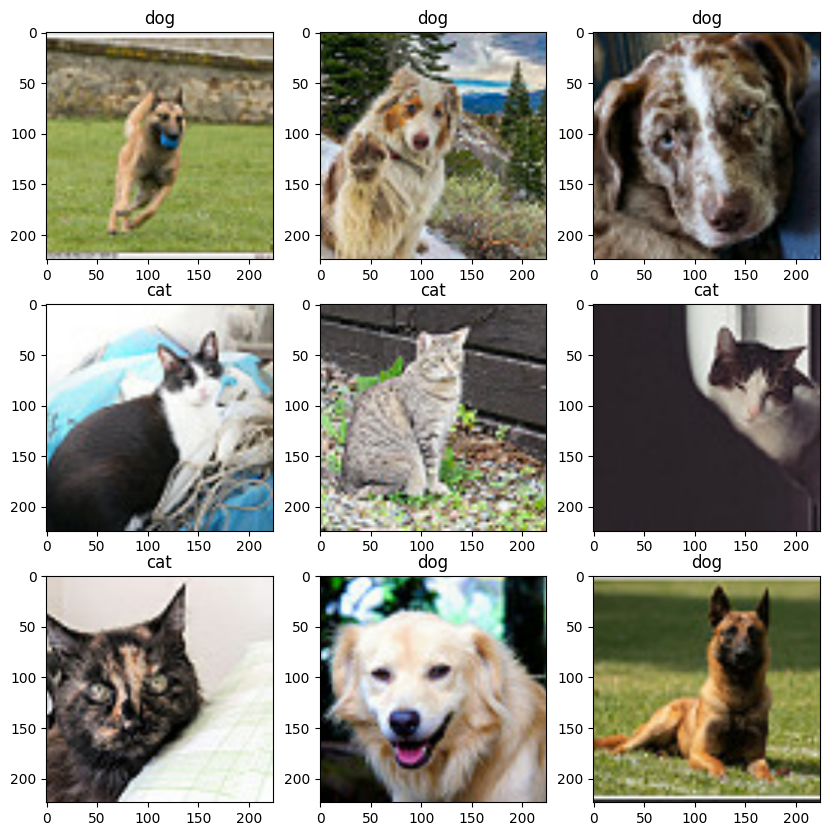

In [4]:
# 訓練データの一部を表示して確認
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy().astype("uint8")[0]])

In [5]:
# 画像の水増しをする関数の定義
def flip_left_right(image, label):   # 左右反転
    image = tf.image.flip_left_right(image)
    return image, label

def flip_up_down(image, label):      # 上下反転
    image = tf.image.flip_up_down(image)
    return image, label

def rot90(image, label):             # 反時計回りに90度回転
    image = tf.image.rot90(image)
    return image, label

def rot180(image, label):            # 反時計回りに180度回転
    image = tf.image.rot90(image, k=2)
    return image, label

def rot270(image, label):            # 反時計回りに270度回転
    image = tf.image.rot90(image, k=3)
    return image, label

In [6]:
# 画像の水増し処理の実行
train_dataset_lr     = train_dataset.map(flip_left_right)
train_dataset_ud     = train_dataset.map(flip_up_down)
train_dataset_rot90  = train_dataset.map(rot90)
train_dataset_rot180 = train_dataset.map(rot180)
train_dataset_rot270 = train_dataset.map(rot270)

In [7]:
# 水増ししたデータを訓練データに追加する
train_dataset = train_dataset.concatenate(train_dataset_lr)
train_dataset = train_dataset.concatenate(train_dataset_ud)
train_dataset = train_dataset.concatenate(train_dataset_rot90)
train_dataset = train_dataset.concatenate(train_dataset_rot180)
train_dataset = train_dataset.concatenate(train_dataset_rot270)

In [8]:
# データをシャッフルする
train_dataset = train_dataset.shuffle(32)

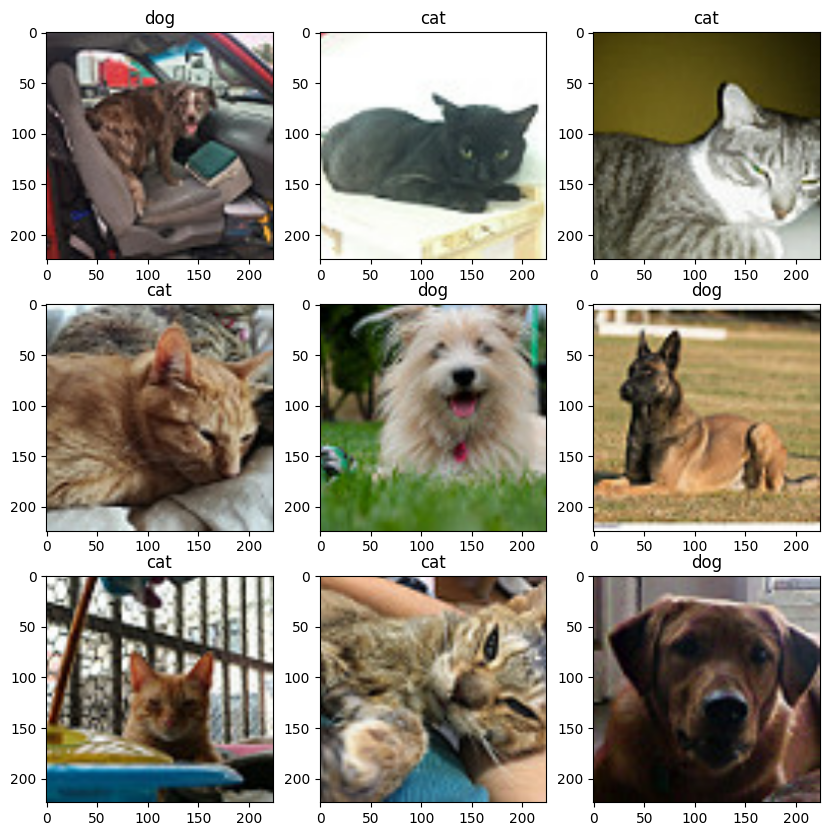

In [9]:
# 訓練データの一部を表示して確認
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy().astype("uint8")[0]])

In [10]:
# MobileNetV2モデルを作成する
input_layer = tf.keras.Input(shape=(224, 224, 3))   # 入力層
l_layer = tf.keras.applications.mobilenet_v2.preprocess_input(input_layer)   # 前処理（正規化）をする層

base_model = tf.keras.applications.mobilenet_v2.MobileNetV2(
    input_shape=(224, 224, 3),
    input_tensor=l_layer,
    include_top=False,
    weights="imagenet",
    pooling='avg'
)
base_model.trainable = False

In [11]:
# Dense層を追加する
output_layer = tf.keras.layers.Dense(1, activation='sigmoid')

In [13]:
# base_modelに先ほどのDense層を追加したモデルを作成する
model = tf.keras.Sequential([
    base_model,
    output_layer
])

In [14]:
# modelをcompileする
model.compile(optimizer="adam",
              loss='binary_crossentropy',
              metrics=["accuracy"])

In [15]:
# modelに学習させる
model.fit(train_dataset, epochs=20)

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 23s 324ms/step - accuracy: 0.8472 - loss: 0.3532
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 28s 458ms/step - accuracy: 0.9250 - loss: 0.2053
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 24s 379ms/step - accuracy: 0.9528 - loss: 0.1570
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 25s 394ms/step - accuracy: 0.9650 - loss: 0.1285
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 25s 406ms/step - accuracy: 0.9694 - loss: 0.1121
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 26s 413ms/step - accuracy: 0.9733 - loss: 0.0975
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 24s 390ms/step - accuracy: 0.9800 - loss: 0.0859
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 24s 382ms/step - accuracy: 0.9817 - loss: 0.0787
Epoch 9/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 22s 347ms/step - accuracy: 0.9844 - loss: 0.0697
Epoch 10/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 22s 353ms/step - accuracy: 0.9878 - loss: 0.0610
Epoch 11/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 23s 366ms/step - accuracy: 0.9900 - loss: 0.0557
Epoch 12/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 24

In [16]:
# テストデータで分類を実行する
pred_data = model.predict(test_dataset)

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 714ms/step


In [17]:
# 分類した結果を確認する
pred_data

array([[1.13022412e-04],
       [1.64691752e-04],
       [2.87591793e-05],
       [1.26460509e-03],
       [5.43909089e-04],
       [1.77822454e-04],
       [3.58326506e-04],
       [6.73840521e-04],
       [3.24812827e-05],
       [4.73102613e-04],
       [3.79334342e-05],
       [4.31873556e-03],
       [2.14836956e-03],
       [6.78534096e-04],
       [3.66729910e-05],
       [3.28504370e-06],
       [6.63837200e-05],
       [5.65735158e-04],
       [6.95628766e-03],
       [1.77273923e-03],
       [7.05349492e-03],
       [6.87340647e-02],
       [4.93598310e-03],
       [7.79473339e-04],
       [2.12412849e-01],
       [9.95696057e-04],
       [7.13340472e-04],
       [5.03545278e-04],
       [5.16736647e-03],
       [1.16478244e-04],
       [5.83851594e-04],
       [6.50313973e-01],
       [4.41965414e-04],
       [6.51582144e-04],
       [6.64749509e-03],
       [7.87239134e-01],
       [4.86840401e-03],
       [8.64880101e-04],
       [4.60183769e-02],
       [2.74219521e-04],


In [18]:
# evaluate()でモデルの性能を評価する
model.evaluate(test_dataset)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 215ms/step - accuracy: 0.9600 - loss: 0.0532


[0.05324169248342514, 0.9599999785423279]